In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

In [11]:
# carga de datos
# normales
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

# escalados
X_train_scaled = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")

# target
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [19]:
# funcion de evaluación
results = []
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print(f"Model: {model.__class__.__name__}")
    print("-" * 40)

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

In [20]:
# Logistic regression (escalado)
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Model: LogisticRegression
----------------------------------------
Accuracy: 0.711
Precision: 0.3881578947368421
Recall: 0.7230392156862745
F1 Score: 0.5051369863013698
ROC-AUC: 0.7797720218740763

Confusion Matrix
[[1127  465]
 [ 113  295]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1592
           1       0.39      0.72      0.51       408

    accuracy                           0.71      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [21]:
# decision tree (sin escalado)
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: DecisionTreeClassifier
----------------------------------------
Accuracy: 0.8035
Precision: 0.5193798449612403
Recall: 0.49264705882352944
F1 Score: 0.5056603773584906
ROC-AUC: 0.6879064439846291

Confusion Matrix
[[1406  186]
 [ 207  201]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      1592
           1       0.52      0.49      0.51       408

    accuracy                           0.80      2000
   macro avg       0.70      0.69      0.69      2000
weighted avg       0.80      0.80      0.80      2000



In [22]:
# Random forest (sin escalado)
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: RandomForestClassifier
----------------------------------------
Accuracy: 0.8685
Precision: 0.8251121076233184
Recall: 0.45098039215686275
F1 Score: 0.5832012678288431
ROC-AUC: 0.8707492733274214

Confusion Matrix
[[1553   39]
 [ 224  184]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1592
           1       0.83      0.45      0.58       408

    accuracy                           0.87      2000
   macro avg       0.85      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [23]:
# XGBoost (sin escalado)
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: XGBClassifier
----------------------------------------
Accuracy: 0.8625
Precision: 0.7435897435897436
Recall: 0.49754901960784315
F1 Score: 0.5961820851688693
ROC-AUC: 0.8713573997438173

Confusion Matrix
[[1522   70]
 [ 205  203]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1592
           1       0.74      0.50      0.60       408

    accuracy                           0.86      2000
   macro avg       0.81      0.73      0.76      2000
weighted avg       0.85      0.86      0.85      2000



In [25]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,XGBClassifier,0.8625,0.743590,0.497549,0.596182,0.871357
2,RandomForestClassifier,0.8685,0.825112,0.450980,0.583201,0.870749
0,LogisticRegression,0.7110,0.388158,0.723039,0.505137,0.779772
1,DecisionTreeClassifier,0.8035,0.519380,0.492647,0.505660,0.687906


| Modelo              | Resultado     |
| ------------------- | ------------- |
| Logistic Regression | buen baseline |
| Decision Tree       | flojo         |
| Random Forest       | muy sólido    |
| XGBoost             | mejor modelo  |


In [ ]:
def plot_confusion_matrix(model, X_test, y_test):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model.__class__.__name__}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# plot_confusion_matrix(
#     xgb_model,
#     X_test,
#     y_test
# )

# RANDOM FOREST

In [28]:
# Randmom Forest feature importance
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
2,age,0.226467
5,numofproducts,0.121048
4,balance,0.112790
8,estimatedsalary,0.100803
10,point_earned,0.098305
0,creditscore,0.095582
3,tenure,0.059942
9,satisfaction_score,0.038736
7,isactivemember,0.032919
11,geography_Germany,0.031272


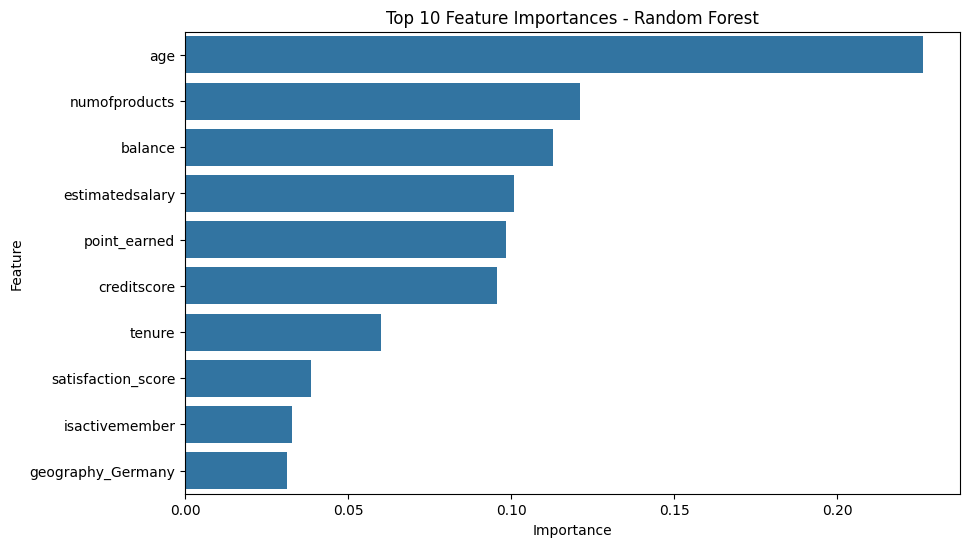

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Random Forest")

plt.show()

# XGB

In [30]:
#  XGBoost feature importance
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
5,numofproducts,0.244102
7,isactivemember,0.182394
2,age,0.145227
11,geography_Germany,0.082199
4,balance,0.053961
1,gender,0.041545
12,geography_Spain,0.033053
0,creditscore,0.028813
10,point_earned,0.028397
9,satisfaction_score,0.025819


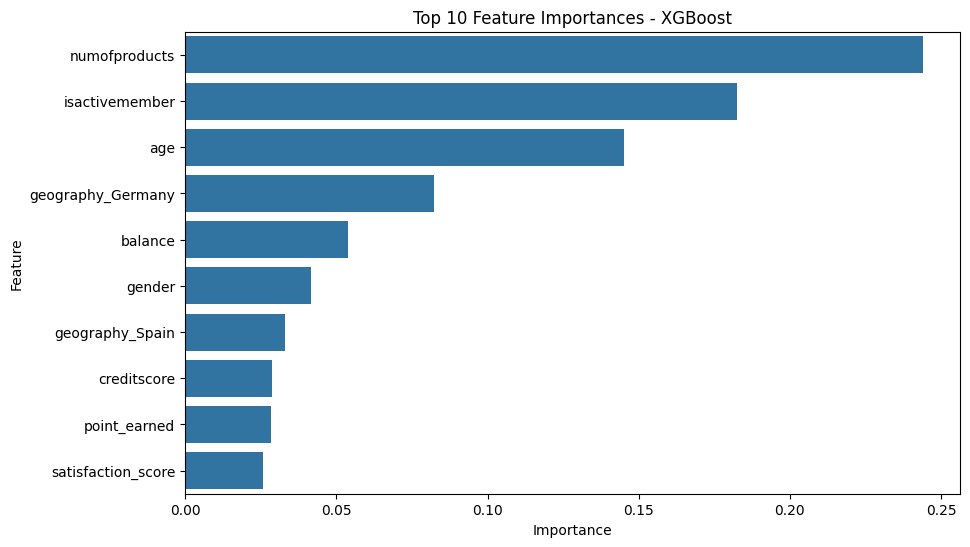

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - XGBoost")

plt.show()

## Guardado de los modelos mas interesantes

In [33]:
joblib.dump(rf, "../models/random_forest.pkl")
joblib.dump(xgb_model, "../models/xgboost.pkl")

['../models/xgboost.pkl']